<a href="https://colab.research.google.com/github/riyapai05/TULU_PROJECT/blob/main/kannada_tulu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CONVNEXT TINY**

In [ ]:
# ============================================================
# COMPLETE CONVNEXT CODE
# TULU vs KANNADA CHARACTER CLASSIFIER
# GOOGLE COLAB READY
# ============================================================

# ============================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install timm -q

# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import shutil
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from PIL import Image
import timm
from google.colab import files

# ============================================================
# STEP 3: UPLOAD ZIP FILES
# ============================================================

print("Upload:")
print("1. Tulu_Dataset_1.zip")
print("2. Kannada_Alphabets.zip")

uploaded = files.upload()

# ============================================================
# STEP 4: EXTRACT ZIP FILES
# ============================================================

extract_path = "/content/datasets"

os.makedirs(extract_path, exist_ok=True)

for zip_file in uploaded.keys():

    print(f"Extracting {zip_file}...")

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("\nExtraction Completed!")

# ============================================================
# STEP 5: CHECK EXTRACTED FOLDERS
# ============================================================

print("\nFolders inside dataset:\n")

for item in os.listdir(extract_path):
    print(item)

# ============================================================
# STEP 6: CREATE COMBINED DATASET
# ============================================================

combined_path = "/content/combined_dataset"

if os.path.exists(combined_path):
    shutil.rmtree(combined_path)

os.makedirs(combined_path)

# YOUR FOLDER NAMES
languages = {
    "tulu": os.path.join(extract_path, "Tulu_Dataset_1"),
    "kannada": os.path.join(extract_path, "Kannada_Alphabets")
}

for language, language_path in languages.items():

    print(f"\nProcessing {language} dataset...")

    if not os.path.exists(language_path):
        print(f"Folder not found: {language_path}")
        continue

    for character in os.listdir(language_path):

        char_path = os.path.join(language_path, character)

        if os.path.isdir(char_path):

            # Create combined class name
            new_class_name = f"{language}_{character}"

            new_class_path = os.path.join(
                combined_path,
                new_class_name
            )

            os.makedirs(new_class_path, exist_ok=True)

            # Copy images
            for image_name in os.listdir(char_path):

                src = os.path.join(char_path, image_name)

                dst = os.path.join(
                    new_class_path,
                    f"{language}_{image_name}"
                )

                shutil.copy(src, dst)

print("\nCombined Dataset Created Successfully!")

print("\nCreated Classes:\n")
print(os.listdir(combined_path))

# ============================================================
# STEP 7: IMAGE TRANSFORMS
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STEP 8: LOAD DATASET
# ============================================================

dataset = ImageFolder(
    root=combined_path,
    transform=transform
)

print("\nDataset Loaded Successfully!")

print("\nClasses:\n")
print(dataset.classes)

num_classes = len(dataset.classes)

print("\nNumber of Classes:", num_classes)

# ============================================================
# STEP 9: SPLIT DATASET
# ============================================================

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("\nTraining Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

# ============================================================
# STEP 10: DEVICE SETUP
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nUsing Device:", device)

# ============================================================
# STEP 11: LOAD CONVNEXT MODEL
# ============================================================

model = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    num_classes=num_classes
)

model.to(device)

print("\nConvNeXt Model Loaded!")

# ============================================================
# STEP 12: LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001
)

# ============================================================
# STEP 13: TRAIN MODEL WITH LIVE PROGRESS
# ============================================================

epochs = 10

for epoch in range(epochs):

    print(f"\n================ EPOCH {epoch+1}/{epochs} ================\n")

    # ================= TRAIN =================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        # LIVE BATCH PRINT
        if (batch_idx + 1) % 10 == 0:

            batch_accuracy = 100 * correct / total

            print(
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"| Loss: {loss.item():.4f} "
                f"| Accuracy: {batch_accuracy:.2f}%"
            )

    train_accuracy = 100 * correct / total

    # ================= VALIDATION =================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print("\n========================================")

    print(f"Epoch [{epoch+1}/{epochs}] Completed")

    print(f"Train Loss       : {running_loss:.4f}")

    print(f"Train Accuracy   : {train_accuracy:.2f}%")

    print(f"Validation Acc   : {val_accuracy:.2f}%")

    print("========================================")

# ============================================================
# STEP 14: SAVE MODEL
# ============================================================

torch.save(model.state_dict(), "tulu_kannada_convnext.pth")

print("\nModel Saved Successfully!")

# ============================================================
# STEP 15: SAVE CLASS NAMES
# ============================================================

class_names = dataset.classes

with open("class_names.txt", "w") as f:

    for item in class_names:
        f.write(item + "\n")

print("Class Names Saved!")

# ============================================================
# STEP 21: DOWNLOAD MODEL FILES
# ============================================================

#files.download("tulu_kannada_convnext.pth")

#files.download("class_names.txt")

Upload:
1. Tulu_Dataset_1.zip
2. Kannada_Alphabets.zip


Saving Kannada_Alphabets.zip to Kannada_Alphabets (1).zip
Saving Tulu_Dataset_1.zip to Tulu_Dataset_1 (1).zip
Extracting Kannada_Alphabets (1).zip...
Extracting Tulu_Dataset_1 (1).zip...

Extraction Completed!

Folders inside dataset:

Kannada_Alphabets
Tulu_Dataset_1

Processing tulu dataset...

Processing kannada dataset...

Combined Dataset Created Successfully!

Created Classes:

['tulu_ತ', 'kannada_ಝ', 'kannada_ಆ', 'tulu_ಛ', 'kannada_ಪ', 'tulu_ಪ', 'tulu_ಥ', 'kannada_ಅಂ', 'tulu_ಯ', 'kannada_ಷ', 'kannada_ಧ', 'kannada_ಇ', 'kannada_ಯ', 'kannada_ಓ', 'tulu_ನ', 'tulu_ೠ', 'kannada_ಸ', 'tulu_ಘ', 'kannada_ಹ', 'kannada_ಅ', 'kannada_ಭ', 'tulu_ಓ', 'tulu_ಅಃ', 'kannada_ರ', 'kannada_ಔ', 'tulu_ಚ', 'tulu_ಐ', 'tulu_ಒ', 'tulu_ಈ', 'kannada_ಳ', 'kannada_ಜ', 'kannada_ಣ', 'kannada_ಖ', 'kannada_ಛ', 'kannada_ಞ', 'tulu_ಎ', 'kannada_ಘ', 'tulu_ಅ', 'tulu_ಋ', 'tulu_ಢ', 'tulu_ಸ', 'tulu_ಊ', 'tulu_ಹ', 'kannada_ಫ', 'kannada_ಊ', 'kannada_ಅಃ', 'kannada_ಈ', 'tulu_ಫ', 'kannada_ಠ', 'kannada_ಎ', 'tulu_ಷ', 'kannada_ವ', 'k

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


ConvNeXt Model Loaded!

================ EPOCH 1/10 ================

Batch [10/122] | Loss: 4.8302 | Accuracy: 1.25%
Batch [20/122] | Loss: 4.6477 | Accuracy: 1.41%
Batch [30/122] | Loss: 4.6125 | Accuracy: 1.46%
Batch [40/122] | Loss: 4.7381 | Accuracy: 1.48%
Batch [50/122] | Loss: 4.5012 | Accuracy: 1.69%
Batch [60/122] | Loss: 4.5779 | Accuracy: 1.61%
Batch [70/122] | Loss: 4.5429 | Accuracy: 1.52%
Batch [80/122] | Loss: 4.5216 | Accuracy: 1.56%
Batch [90/122] | Loss: 4.4848 | Accuracy: 1.46%
Batch [100/122] | Loss: 4.6102 | Accuracy: 1.47%
Batch [110/122] | Loss: 4.5032 | Accuracy: 1.53%
Batch [120/122] | Loss: 3.9882 | Accuracy: 1.85%

Epoch [1/10] Completed
Train Loss       : 552.3124
Train Accuracy   : 1.85%
Validation Acc   : 4.51%

================ EPOCH 2/10 ================

Batch [10/122] | Loss: 3.8453 | Accuracy: 8.12%
Batch [20/122] | Loss: 2.7568 | Accuracy: 13.91%
Batch [30/122] | Loss: 2.7093 | Accuracy: 17.60%
Batch [40/122] | Loss: 2.2422 | Accuracy: 23.12%
Batch 


Upload Test Image For Prediction


Saving Screenshot 2026-05-07 181931.png to Screenshot 2026-05-07 181931.png


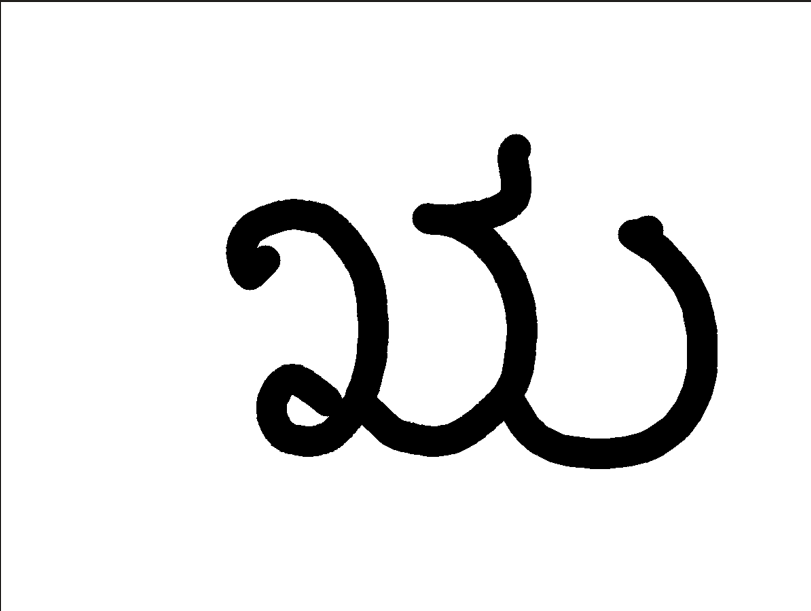


      PREDICTION RESULT

Predicted Language : KANNADA
Predicted Character: ಋ
Confidence Score   : 98.51%



In [ ]:
# ============================================================
# STEP 16: UPLOAD TEST IMAGE
# ============================================================

print("\nUpload Test Image For Prediction")

uploaded_test = files.upload()

test_image_path = list(uploaded_test.keys())[0]

# ============================================================
# STEP 17: PREDICTION TRANSFORM
# ============================================================

prediction_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STEP 18: LOAD IMAGE
# ============================================================

image = Image.open(test_image_path).convert("RGB")

display(image)

input_tensor = prediction_transform(image)

input_tensor = input_tensor.unsqueeze(0).to(device)

# ============================================================
# STEP 19: PREDICT
# ============================================================

model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, 1)

predicted_class = class_names[predicted.item()]

# Example:
# tulu_a
# kannada_ka

language, character = predicted_class.split("_", 1)

# ============================================================
# STEP 20: DISPLAY RESULT
# ============================================================

print("\n==============================")
print("      PREDICTION RESULT")
print("==============================")

print(f"\nPredicted Language : {language.upper()}")

print(f"Predicted Character: {character}")

print(f"Confidence Score   : {confidence.item()*100:.2f}%")

print("\n==============================")


**CONVNEXT-SMALL**

In [ ]:
# ============================================================
# STEP 11: LOAD CONVNEXT SMALL MODEL
# ============================================================

model = timm.create_model(
    "convnext_small",
    pretrained=True,
    num_classes=num_classes
)

model.to(device)

print("\nConvNeXt Small Model Loaded!")


ConvNeXt Small Model Loaded!


In [ ]:
# ============================================================
# STEP 12: LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001
)

In [ ]:
# ============================================================
# STEP 13: TRAIN MODEL
# ============================================================

epochs = 10

for epoch in range(epochs):

    print(f"\n================ EPOCH {epoch+1}/{epochs} ================\n")

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 10 == 0:

            batch_accuracy = 100 * correct / total

            print(
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"| Loss: {loss.item():.4f} "
                f"| Accuracy: {batch_accuracy:.2f}%"
            )

    train_accuracy = 100 * correct / total

    # ================= VALIDATION =================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print("\n========================================")

    print(f"Epoch [{epoch+1}/{epochs}] Completed")

    print(f"Train Loss       : {running_loss:.4f}")

    print(f"Train Accuracy   : {train_accuracy:.2f}%")

    print(f"Validation Acc   : {val_accuracy:.2f}%")

    print("========================================")


================ EPOCH 1/10 ================

Batch [10/122] | Loss: 4.6526 | Accuracy: 0.94%
Batch [20/122] | Loss: 4.6592 | Accuracy: 0.78%
Batch [30/122] | Loss: 4.4877 | Accuracy: 1.15%
Batch [40/122] | Loss: 4.5247 | Accuracy: 1.41%
Batch [50/122] | Loss: 4.6086 | Accuracy: 1.38%
Batch [60/122] | Loss: 4.5362 | Accuracy: 1.72%
Batch [70/122] | Loss: 4.6383 | Accuracy: 1.79%
Batch [80/122] | Loss: 4.5458 | Accuracy: 1.72%
Batch [90/122] | Loss: 4.3454 | Accuracy: 1.74%
Batch [100/122] | Loss: 3.7227 | Accuracy: 2.66%
Batch [110/122] | Loss: 2.8639 | Accuracy: 4.03%
Batch [120/122] | Loss: 2.5796 | Accuracy: 5.86%

Epoch [1/10] Completed
Train Loss       : 516.2948
Train Accuracy   : 6.25%
Validation Acc   : 38.01%

================ EPOCH 2/10 ================

Batch [10/122] | Loss: 2.0104 | Accuracy: 42.81%
Batch [20/122] | Loss: 1.2533 | Accuracy: 50.16%
Batch [30/122] | Loss: 1.5332 | Accuracy: 54.90%
Batch [40/122] | Loss: 1.4033 | Accuracy: 56.17%
Batch [50/122] | Loss: 1.293

In [ ]:
# ============================================================
# STEP 14: SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "tulu_kannada_convnext_smalll.pth"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [ ]:
# ============================================================
# STEP 15: LOAD MODEL FOR PREDICTION
# ============================================================

predict_model = timm.create_model(
    "convnext_small",
    pretrained=False,
    num_classes=num_classes
)

predict_model.load_state_dict(
    torch.load(
        "tulu_kannada_convnext_small.pth",
        map_location=device
    )
)

predict_model.to(device)

predict_model.eval()

print("\nPrediction Model Loaded!")


Prediction Model Loaded!



Upload Test Image For Prediction


Saving aa.png to aa (5).png


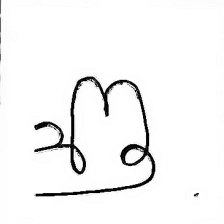


      PREDICTION RESULT

Predicted Language : TULU
Predicted Character: ಆ
Confidence Score   : 99.99%



In [ ]:
# ============================================================
# STEP 16 TO STEP 20 : COMPLETE PREDICTION
# ============================================================

print("\nUpload Test Image For Prediction")

uploaded_test = files.upload()

test_image_path = list(uploaded_test.keys())[0]

# ============================================================
# PREDICTION TRANSFORM
# ============================================================

prediction_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# LOAD IMAGE
# ============================================================

image = Image.open(test_image_path).convert("RGB")

display(image)

input_tensor = prediction_transform(image)

input_tensor = input_tensor.unsqueeze(0).to(device)

# ============================================================
# PREDICT
# ============================================================

model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, 1)

predicted_class = class_names[predicted.item()]

# Example:
# tulu_a
# kannada_ka

language, character = predicted_class.split("_", 1)

# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n==============================")
print("      PREDICTION RESULT")
print("==============================")

print(f"\nPredicted Language : {language.upper()}")

print(f"Predicted Character: {character}")

print(f"Confidence Score   : {confidence.item()*100:.2f}%")

print("\n==============================")

**SWIN**

In [ ]:
# ============================================================
# STEP 11: LOAD SWIN TRANSFORMER MODEL
# ============================================================

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=num_classes
)

model.to(device)

print("\nSwin Transformer Model Loaded!")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Swin Transformer Model Loaded!


In [ ]:
# ============================================================
# STEP 12: LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001
)

In [ ]:
# ============================================================
# STEP 13: TRAIN MODEL
# ============================================================

epochs = 10

for epoch in range(epochs):

    print(f"\n================ EPOCH {epoch+1}/{epochs} ================\n")

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 10 == 0:

            batch_accuracy = 100 * correct / total

            print(
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"| Loss: {loss.item():.4f} "
                f"| Accuracy: {batch_accuracy:.2f}%"
            )

    train_accuracy = 100 * correct / total

    # ================= VALIDATION =================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print("\n========================================")

    print(f"Epoch [{epoch+1}/{epochs}] Completed")

    print(f"Train Loss       : {running_loss:.4f}")

    print(f"Train Accuracy   : {train_accuracy:.2f}%")

    print(f"Validation Acc   : {val_accuracy:.2f}%")

    print("========================================")


================ EPOCH 1/10 ================

Batch [10/122] | Loss: 4.5447 | Accuracy: 1.88%
Batch [20/122] | Loss: 4.5013 | Accuracy: 1.25%
Batch [30/122] | Loss: 4.5353 | Accuracy: 1.77%
Batch [40/122] | Loss: 3.7254 | Accuracy: 2.73%
Batch [50/122] | Loss: 3.5990 | Accuracy: 4.44%
Batch [60/122] | Loss: 2.9319 | Accuracy: 7.14%
Batch [70/122] | Loss: 2.3172 | Accuracy: 10.36%
Batch [80/122] | Loss: 2.8130 | Accuracy: 13.20%
Batch [90/122] | Loss: 2.1566 | Accuracy: 16.70%
Batch [100/122] | Loss: 1.6149 | Accuracy: 19.62%
Batch [110/122] | Loss: 1.8125 | Accuracy: 23.04%
Batch [120/122] | Loss: 1.1996 | Accuracy: 26.64%

Epoch [1/10] Completed
Train Loss       : 377.8902
Train Accuracy   : 27.22%
Validation Acc   : 69.67%

================ EPOCH 2/10 ================

Batch [10/122] | Loss: 0.9343 | Accuracy: 70.00%
Batch [20/122] | Loss: 1.0728 | Accuracy: 70.62%
Batch [30/122] | Loss: 0.9512 | Accuracy: 71.56%
Batch [40/122] | Loss: 1.2625 | Accuracy: 71.48%
Batch [50/122] | Loss

In [ ]:
# ============================================================
# STEP 14: SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "tulu_kannada_swin.pth"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [ ]:
# ============================================================
# STEP 15: LOAD MODEL FOR PREDICTION
# ============================================================

predict_model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=num_classes
)

predict_model.load_state_dict(
    torch.load(
        "tulu_kannada_swin.pth",
        map_location=device
    )
)

predict_model.to(device)

predict_model.eval()

print("\nPrediction Model Loaded!")


Prediction Model Loaded!



Upload Test Image For Prediction


Saving Screenshot 2026-05-07 181931.png to Screenshot 2026-05-07 181931 (2).png


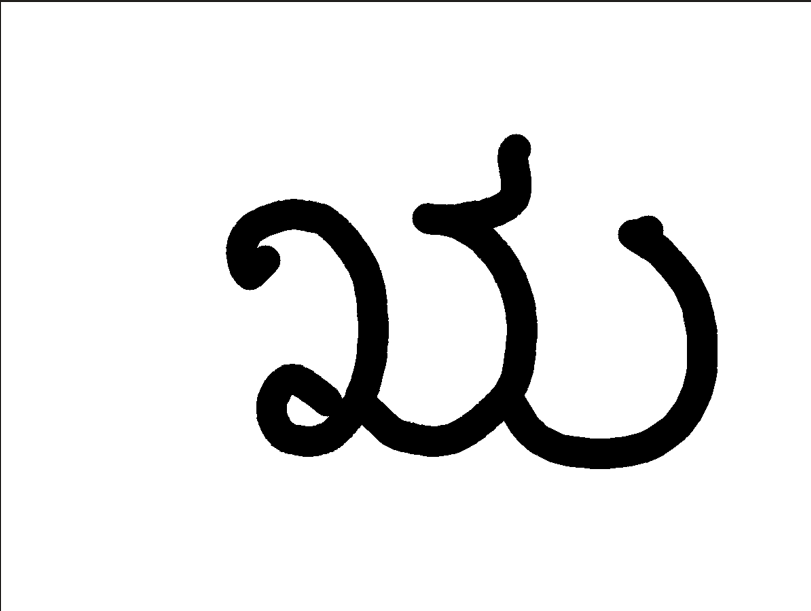


      PREDICTION RESULT

Predicted Language : KANNADA
Predicted Character: ಋ
Confidence Score   : 99.90%



In [ ]:
# ============================================================
# STEP 16 TO STEP 20 : COMPLETE PREDICTION
# ============================================================

print("\nUpload Test Image For Prediction")

uploaded_test = files.upload()

test_image_path = list(uploaded_test.keys())[0]

# ============================================================
# PREDICTION TRANSFORM
# ============================================================

prediction_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# LOAD IMAGE
# ============================================================

image = Image.open(test_image_path).convert("RGB")

display(image)

input_tensor = prediction_transform(image)

input_tensor = input_tensor.unsqueeze(0).to(device)

# ============================================================
# PREDICT
# ============================================================

model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, 1)

predicted_class = class_names[predicted.item()]

# Example:
# tulu_a
# kannada_ka

language, character = predicted_class.split("_", 1)

# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n==============================")
print("      PREDICTION RESULT")
print("==============================")

print(f"\nPredicted Language : {language.upper()}")

print(f"Predicted Character: {character}")

print(f"Confidence Score   : {confidence.item()*100:.2f}%")

print("\n==============================")